In [ ]:
!pip install scikit-learn
!pip install seaborn
!pip install imblearn
!pip install sklearn
!pip install shapely
!pip install eli5
!pip install shap
!pip install numpy

In [3]:
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.svm import SVR
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, precision_recall_fscore_support, accuracy_score
from sklearn import preprocessing
from sklearn.model_selection import StratifiedShuffleSplit
from datetime import datetime
import geopandas as gpd
import numpy as np
import glob

# Loading multiple CSVs to merge the samples - if it is the case:

In [ ]:

# Specify the directory where the CSV files are located
directory = r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1'

# Use the glob module to retrieve a list of file paths that match the pattern '*.csv' in the specified directory and its subdirectories
#file_list = glob.glob(directory + '/**/*.csv', recursive=True)

# Create an empty dataframe to store the concatenated data
#df = pd.DataFrame()

# Loop through the file list and read each CSV file using pd.read_csv(), and concatenate it to the dataframe
"""
for file in file_list:
    df_temp = pd.read_csv(file)
    # Extract the date from the filename (assuming the filename has a date string in it)
    date_str = file.split('LARGO1')[1].split("\\")[1]
    if date_str == '11-17-2021' or date_str == '10-07-2021' or date_str == '10-26-2021':
        continue
    date_obj = datetime.strptime(date_str, '%m-%d-%Y')
    desired_year = 2021
    correct_date_obj = date_obj.replace(year=desired_year)

    formatted_date_str = correct_date_obj.strftime('%m/%d/%Y')
    date = pd.to_datetime(formatted_date_str).date()
    
    # Add a new column for the date
    df_temp['date'] = date
    print('Dataset for date', date, 'added.')

    df = pd.concat([df, df_temp], ignore_index=True)
"""


# Loading training and target dataframes

In [4]:
df = []
df1 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\08-30-2021\VALUES\values.csv')
df2 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\09-24-2021\VALUES\values.csv')
df3 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\10-05-2021\VALUES\values.csv')
df4 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\10-07-2021\VALUES\values.csv')
df5 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\10-26-2021\VALUES\values.csv')
df.append(df1)
#df.append(df2)
#df.append(df3)
#df.append(df4)
#df.append(df5)
df = pd.concat(df, ignore_index=True)
df_target = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\09-24-2021\VALUES\values.csv')
#df_target = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\11-17-2021\VALUES\values.csv')
#df_target = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\11-17-2021\VALUES\values.csv')
#df_target = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\11-17-2021\VALUES\values.csv')

# Getting a valid date type from the filenames:

In [ ]:
"""
date_str = '0830'
date_obj = datetime.strptime(date_str, '%m%d')
desired_year = 2021
correct_date_obj = date_obj.replace(year=desired_year)
formatted_date_str = correct_date_obj.strftime('%m/%d/%Y')
print(formatted_date_str)
date = pd.to_datetime(formatted_date_str).date()
df['date'] = date

date_str = '1117'
date_obj = datetime.strptime(date_str, '%m%d')
desired_year = 2021
correct_date_obj = date_obj.replace(year=desired_year)
formatted_date_str = correct_date_obj.strftime('%m/%d/%Y')
date = pd.to_datetime(formatted_date_str).date()
df_target['date'] = date
"""

invalid value encountered in subtract
invalid value encountered in subtract
invalid value encountered in subtract
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


DF TARGET HEALTH CLASSES: [0, 1, 2]
DF TARGET HEALTH CLASSES: [0, 1, 2]
           0         1         2         3         4         5         6   \
0    0.464967  0.612681  0.327561  0.576813  0.379696  0.477812  0.626096   
1    0.463823  0.735719  0.596284  0.381403  0.379696  0.666679  0.638820   
2    0.388576  0.710677  0.410062  0.362515  0.139089  0.619813  0.786788   
3    0.493294  0.706018  0.316477  0.412726  0.379696  0.642902  0.876091   
4    0.472508  0.696003  0.126516  0.540758  0.379696  0.581652  0.896743   
..        ...       ...       ...       ...       ...       ...       ...   
155  0.494791  0.631175  0.601880  0.414088  0.379696  0.630479  0.623721   
156  0.332878  0.395594  0.437147  0.416305  0.379696  0.357297  0.469009   
157  0.537481  0.723612  0.670052  0.394721  0.379696  0.744362  0.668981   
158  0.687890  0.630103  0.567925  0.676802  0.379696  0.591283  0.503744   
159  0.800546  0.735320  0.329376  0.779318  0.379696  0.705455  0.710684   

   

<Axes: >

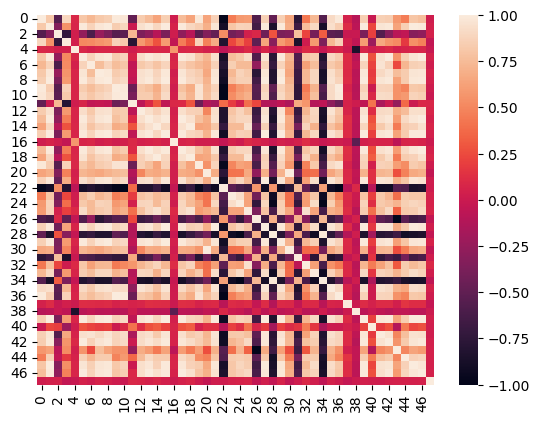

In [14]:

def remove_outliers_iqr(df, column, threshold=1.5):
    # Separate the label column from the features
    X = df.drop(column, axis=1)
    y = df[column]

    q1 = X.quantile(0.25)
    q3 = X.quantile(0.75)
    iqr = q3 - q1
    lower_threshold = q1 - threshold * iqr
    upper_threshold = q3 + threshold * iqr
    
    # Create a mask to identify outliers in each column
    outlier_mask = (X < lower_threshold) | (X > upper_threshold)
    
    # Remove outliers by replacing with NaN or dropping the rows
    X_no_outliers = X.mask(outlier_mask)
    y_no_outliers = y.mask(outlier_mask.any(axis=1))
    
    # Concatenate the features and label back together
    df_no_outliers = pd.concat([X_no_outliers, y_no_outliers], axis=1)

    return df_no_outliers


# Cleaning and normalizing the training and the target dataframe (i.e., df and df_target)
# so that AVERAGE, HEALTHY, and UNHEALTHY labels become [0, ]
df = remove_outliers_iqr(df, 'HEALTH_STA')
df = df[df['HEALTH_STA'].notna()]

le = preprocessing.LabelEncoder()
le.fit(df['HEALTH_STA'])
print('DF TARGET HEALTH CLASSES:', list(le.classes_))
df['HEALTH_STA'] = le.transform(df['HEALTH_STA'])

# loading the dataframe for the next date
de_target = remove_outliers_iqr(df_target, 'HEALTH_STA')
df_target = df_target[df_target['HEALTH_STA'].notna()]
le = preprocessing.LabelEncoder()
le.fit(df_target['HEALTH_STA'])
print('DF TARGET HEALTH CLASSES:', list(le.classes_))
df_target['HEALTH_STA'] = le.transform(df_target['HEALTH_STA'])

## Feature & Target Selection for the training dataframe (df)
X = df[[col for col in df.columns]]
X = X.drop(df.columns[0], axis=1) # Droping the first dataframe's column (with IDs)
X = X.drop('HEALTH_STA', axis=1) # Droping the label column from the dataframe
features = X.columns
# X = X.drop('date', axis=1)
y = df['HEALTH_STA']
labels = y.unique()
print(features)

# Removing inf values
X.replace([np.inf, -np.inf], np.nan, inplace=True)
mean_values = X.mean(axis=0)
X.fillna(mean_values, inplace=True)


# Putting the pixels and vegetation indices values into a scale from 0 to 1
min_max_scaler = preprocessing.MinMaxScaler()
x_scaled = min_max_scaler.fit_transform(X)
X = pd.DataFrame(x_scaled)

X = X.astype(float)

#from imblearn.over_sampling import RandomOverSampler

# X_train and y_train are your feature matrix and target labels respectively

print('Unbalanced dataset for training:')
class_counts = np.bincount(y)
print(class_counts)

#majority_class_size = np.max(class_counts)
#sampling_strategy = {i: majority_class_size*1 for i in range(len(class_counts)) if class_counts[i] < majority_class_size}
# create an instance of the RandomOverSampler class
#ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=42)

#X_resampled, y_resampled = ros.fit_resample(X, y)

# Split the train and test sets into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# Split the train and test sets into train and test sets again
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

X_next_date = df_target[[col for col in df_target.columns]]
X_next_date = X_next_date.drop('HEALTH_STA', axis=1)
# X_next_date = X_next_date.drop('date', axis=1)
X_next_date = X_next_date.drop(X_next_date.columns[0], axis=1) # Droping the first dataframe's column (with IDs)
y_next_date = df_target['HEALTH_STA']
y_next_date = y_next_date.dropna()

X_next_date.replace([np.inf, -np.inf], np.nan, inplace=True)
next_date_mean_values = X_next_date.mean(axis=0)
X_next_date.fillna(next_date_mean_values, inplace=True)

min_max_scaler = preprocessing.MinMaxScaler()
x_next_date_scaled = min_max_scaler.fit_transform(X_next_date)
X_next_date = pd.DataFrame(x_next_date_scaled)

X_next_date = X_next_date.astype(float)

class_counts = np.bincount(y_next_date)

#print('Balanced dataset for training (after oversampling):')
#counts = np.bincount(y_train)
#print(counts)

from imblearn.over_sampling import RandomOverSampler

# X_train and y_train are your feature matrix and target labels respectively
#majority_class_size = np.max(class_counts)
#sampling_strategy = {i: majority_class_size*1 for i in range(len(class_counts)) if class_counts[i] < majority_class_size}

# create an instance of the RandomOverSampler class
#ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=42)

#X_next_date_resampled, y_next_date_resampled = ros.fit_resample(X_next_date, y_next_date)

# Split the train and test sets into train and test sets
X_next_date_train, X_next_date_test, y_next_date_train, y_next_date_test = train_test_split(X_next_date, y_next_date, stratify=y_next_date, test_size=0.3, random_state=42)

class_counts = np.bincount(y_next_date_test)
print('Splitted unbalanced dataset for testing with the last date:')
print(class_counts)

# preview train & test sets
print('Train Set:', X_train.shape, y_train.shape)
print('Next Date Test Set:', X_next_date_test.shape, y_next_date_test.shape)

# build, train, & predict model
model = SVC(kernel='rbf', C=0.00001, gamma='auto', probability=True, decision_function_shape='ovr', break_ties=True, random_state=42)
model.fit(X_train, y_train)
y_pred_svc = model.predict(X_next_date_test)

# evaluate results
print('##### SVC Metrics:')
print('MAE:', mean_absolute_error(y_next_date_test, y_pred_svc))
print('MSE:', mean_squared_error(y_next_date_test, y_pred_svc))
print('R2 Score:', r2_score(y_next_date_test, y_pred_svc))
print('F1-SCORE: ', f1_score(y_next_date_test, y_pred_svc, average='micro'))
print('TEST ACCURACY SCORE:', accuracy_score(y_next_date_test, y_pred_svc))

# Calculate accuracy per label
label_accuracy = precision_recall_fscore_support(y_next_date_test, y_pred_svc, average=None)
# The 'average=None' argument returns precision, recall, and F1-score for each label separately

# Print the accuracy per label
for label, accuracy in zip(labels, label_accuracy[0]):
    print(f"Label {label}: Test Accuracy = {accuracy}")

#y_pred_svc_val = y_pred = model.predict(X_next_date_test)
#print('VALIDATION ACCURACY SCORE:', accuracy_score(y_next_date_test, y_pred))

# Calculate accuracy per label
#label_accuracy = precision_recall_fscore_support(y_val, y_pred, average=None)
# The 'average=None' argument returns precision, recall, and F1-score for each label separately

# Print the accuracy per label
#for label, accuracy in zip(labels, label_accuracy[0]):
#    print(f"Label {label}: Validation Accuracy = {accuracy}")

# Concatenating X and y to check the correlation values
combined_df = pd.concat([X, y], axis=1)
correlation_matrix = combined_df.corr()

import seaborn as sns
sns.heatmap(correlation_matrix)


# RANDOM FOREST MODEL:

In [ ]:

import numpy as np

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
param_grid = { 
    'n_estimators': [100, 200, 500],
    'max_features': [5, 'sqrt', 'log2'],
    'max_depth' : [4,5,6,7,8],
    'criterion' :['entropy', 'gini']
}

from scipy.stats import uniform

print('##### Random Forest Classifier')
rfc = RandomForestClassifier(random_state=42)
CV_rfc = GridSearchCV(estimator=rfc, param_grid=param_grid, cv=10)

# fit
CV_rfc.fit(X_train, y_train)
print('Best Params Grid Search:')
print(CV_rfc.best_params_)

# Instantiate RandomizedSearchCV model
rs_model = RandomizedSearchCV(RandomForestClassifier(n_jobs=-1, random_state=42),
                               param_distributions=param_grid,
                               n_iter=10,
                               cv=10,
                               verbose=True)
rs_model.fit(X_train, y_train)
print('Best Params RandomizedSearch (RF):')
print(rs_model.best_params_)
best_params = rs_model.best_params_

print('Metrics (RFO)')
rfc_best = RandomForestClassifier(**best_params)
rfc_best.fit(X_train, y_train)
y_pred_rfc = rfc_best.predict(X_next_date_test)

print('MAE:', mean_absolute_error(y_next_date_test, y_pred_rfc))
print('MSE:', mean_squared_error(y_next_date_test, y_pred_rfc))
print('R2 Score:', r2_score(y_next_date_test, y_pred_rfc))
print('F1-SCORE: ', f1_score(y_next_date_test, y_pred_rfc, average='micro'))
print('TEST ACCURACY SCORE:', accuracy_score(y_next_date_test, y_pred_rfc))

# Calculate accuracy per label
label_accuracy = precision_recall_fscore_support(y_next_date_test, y_pred_rfc, average=None)
# The 'average=None' argument returns precision, recall, and F1-score for each label separately

# Print the accuracy per label
for label, accuracy in zip(labels, label_accuracy[0]):
    print(f"Label {label}: Test Accuracy = {accuracy}")

#y_pred_rfc_val = rfc_best.predict(X_next_date_test)
#print('VALIDATION ACCURACY SCORE:', accuracy_score(y_next_date_test, y_pred_rfc_val))

# Calculate accuracy per label
#label_accuracy = precision_recall_fscore_support(y_next_date_test, y_pred_rfc_val, average=None)
# The 'average=None' argument returns precision, recall, and F1-score for each label separately

## Print the accuracy per label
#for label, accuracy in zip(labels, label_accuracy[0]):
#    print(f"Label {label}: Validation Accuracy = {accuracy}")



# Performing a CNN classification task:

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from keras.wrappers.scikit_learn import KerasClassifier


# Build the CNN model
def create_cnn_model():
    cnn_model = Sequential()
    cnn_model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
    cnn_model.add(Dense(64, activation='relu'))
    cnn_model.add(Dense(1, activation='sigmoid'))
    
    # Compile the model
    cnn_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return cnn_model

cnn_model = KerasClassifier(build_fn=create_cnn_model, epochs=100, batch_size=32, verbose=0)

# Train the model
cnn_model.fit(X_train, y_train, epochs=100, batch_size=32)

y_pred_cnn = cnn_model.predict(X_next_date_test)

# evaluate results
print('##### CNN Metrics:')
print('MAE:', mean_absolute_error(y_next_date_test, y_pred_cnn))
print('MSE:', mean_squared_error(y_next_date_test, y_pred_cnn))
print('R2 Score:', r2_score(y_next_date_test, y_pred_cnn))
y_pred_cnn_labels = np.argmax(y_pred_cnn, axis=1)
print('F1-SCORE: ', f1_score(y_next_date_test, y_pred_cnn_labels, average='weighted'))
print('TEST ACCURACY SCORE:', accuracy_score(y_next_date_test, y_pred_cnn_labels))

# Calculate accuracy per label
label_accuracy = precision_recall_fscore_support(y_next_date_test, y_pred_cnn_labels, average=None)
# The 'average=None' argument returns precision, recall, and F1-score for each label separately

# Print the accuracy per label
for label, accuracy in zip(labels, label_accuracy[0]):
    print(f"Label {label}: Test Accuracy = {accuracy}")

In [127]:
from tensorflow import keras

# define the model architecture

inputs = keras.Input(shape=(47,))
x = keras.layers.Dense(64, activation='relu')(inputs)
x = keras.layers.Dense(128, activation='relu')(x)
x = keras.layers.Dense(64, activation='relu')(x)
x = keras.layers.Dense(32, activation='relu')(x)
x = keras.layers.Dense(16, activation='relu')(x)
outputs = keras.layers.Dense(10, activation='softmax')(x)
# inputs and outputs
cnn_model_2 = keras.Model(inputs=inputs, outputs=outputs, name="test_for_shap")
# compile the model
cnn_model_2.compile(
      loss=keras.losses.SparseCategoricalCrossentropy(),
      optimizer=keras.optimizers.Adam(),
      metrics=[keras.metrics.SparseCategoricalAccuracy()]
  )

cnn_model_2.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10)


Epoch 1/10
4/4 [==============================] - 1s 64ms/step - loss: 2.3304 - sparse_categorical_accuracy: 0.0794 - val_loss: 2.1605 - val_sparse_categorical_accuracy: 0.4909
Epoch 2/10
4/4 [==============================] - 0s 19ms/step - loss: 2.0538 - sparse_categorical_accuracy: 0.7222 - val_loss: 1.8697 - val_sparse_categorical_accuracy: 0.8364
Epoch 3/10
4/4 [==============================] - 0s 15ms/step - loss: 1.7056 - sparse_categorical_accuracy: 0.8413 - val_loss: 1.4700 - val_sparse_categorical_accuracy: 0.8364
Epoch 4/10
4/4 [==============================] - 0s 17ms/step - loss: 1.2619 - sparse_categorical_accuracy: 0.8413 - val_loss: 1.0426 - val_sparse_categorical_accuracy: 0.8364
Epoch 5/10
4/4 [==============================] - 0s 21ms/step - loss: 0.8581 - sparse_categorical_accuracy: 0.8413 - val_loss: 0.7893 - val_sparse_categorical_accuracy: 0.8364
Epoch 6/10
4/4 [==============================] - 0s 20ms/step - loss: 0.6994 - sparse_categorical_accuracy: 0.8413

# Performing a XGBoost classification

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

# declare parameters
params = {
            'objective':'binary:logistic',
            'max_depth': 4,
            'alpha': 10,
            'learning_rate': 1.0,
            'n_estimators':100
        } 
            
            
# instantiate the classifier 
xgb_clf = XGBClassifier(**params)
xgb_clf.fit(X_train, y_train)

y_pred_xgb = cnn_model.predict(X_next_date_test)

# evaluate results
print('##### CNN Metrics:')
print('MAE:', mean_absolute_error(y_next_date_test, y_pred_xgb))
print('MSE:', mean_squared_error(y_next_date_test, y_pred_xgb))
print('R2 Score:', r2_score(y_next_date_test, y_pred_xgb))
y_pred_xgb_labels = np.argmax(y_pred_xgb, axis=1)
print('F1-SCORE: ', f1_score(y_next_date_test, y_pred_xgb_labels, average='weighted'))
print('TEST ACCURACY SCORE:', accuracy_score(y_next_date_test, y_pred_xgb_labels))

# Calculate accuracy per label
label_accuracy = precision_recall_fscore_support(y_next_date_test, y_pred_xgb_labels, average=None)
# The 'average=None' argument returns precision, recall, and F1-score for each label separately

# Print the accuracy per label
for label, accuracy in zip(labels, label_accuracy[0]):
    print(f"Label {label}: Test Accuracy = {accuracy}")

In [ ]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

# Define the number of folds (k)
k = 10

# Create an instance of the k-fold cross-validator
kfold = KFold(n_splits=k, shuffle=True, random_state=42)

# Perform k-fold cross-validation
scores = cross_val_score(model, X_next_date_test, y_next_date_test, cv=kfold)
rfc_scores = cross_val_score(rfc_best, X_next_date_test, y_next_date_test, cv=kfold)
cnn_scores = cross_val_score(cnn_model, X_next_date_test, y_next_date_test, cv=kfold)
xgb_scores = cross_val_score(xgb_clf, X_next_date_test, y_next_date_test, cv=kfold)

# Print the cross-validation scores
print('\n SVC:')
print("Cross-validation scores:", scores)
print("Average score:", scores.mean())

print('\n RFC:')
print("Cross-validation scores:", rfc_scores)
print("Average score:", rfc_scores.mean())

print('\n CNN:')
print("Cross-validation scores:", cnn_scores)
print("Average score:", cnn_scores.mean())

print('\n XGB:')
print("Cross-validation scores:", xgb_scores)
print("Average score:", xgb_scores.mean())

In [ ]:
# Plot the confusion matrix for the SVM model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = ['Healthy', 'Unhealthy', 'Average']
f, axes = plt.subplots(1, 3, figsize=(20, 5), sharey='row')

cm = confusion_matrix(y_next_date_test, y_pred_svc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[0], xticks_rotation=45)
disp.ax_.set_title("Support Vector Classifier")
disp.im_.colorbar.remove()
disp.ax_.set_xlabel('')


# Plot the confusion matrix for the Random Forest model
cm = confusion_matrix(y_next_date_test, y_pred_rfc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[1], xticks_rotation=45)
disp.ax_.set_title("Random Forest")
disp.im_.colorbar.remove()
disp.ax_.set_xlabel('')
disp.ax_.set_ylabel('')

cm = confusion_matrix(y_next_date_test, y_pred_cnn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[2], xticks_rotation=45)
disp.ax_.set_title("CNN")
disp.im_.colorbar.remove()
disp.ax_.set_xlabel('')
disp.ax_.set_ylabel('')

f.text(0.4, -0.05, 'Predicted label', ha='left')
plt.subplots_adjust(wspace=0.20, hspace=0.1)

f.colorbar(disp.im_, ax=axes)
plt.show()

Text(0.5, 0, 'Permutation Importance')

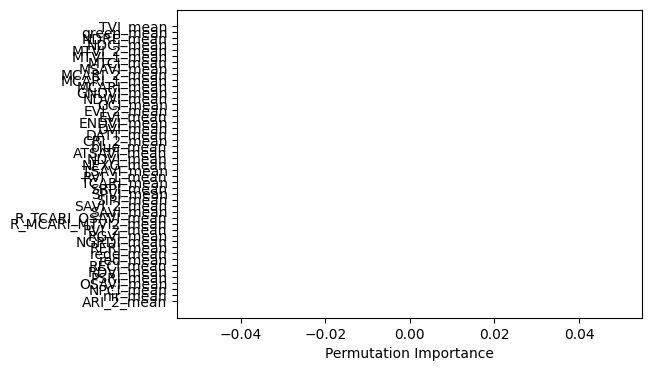

In [136]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(model, X_next_date_test, y_next_date_test)

class_names = [col for col in df.columns if col != 'HEALTH_STA' and col != 'Unnamed: 0']
features = np.array(class_names)

sorted_idx = perm_importance.importances_mean.argsort()
plt.barh(features[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance")

3/3 [==============================] - 0s 3ms/step
Columns


FixedFormatter should only be used together with FixedLocator


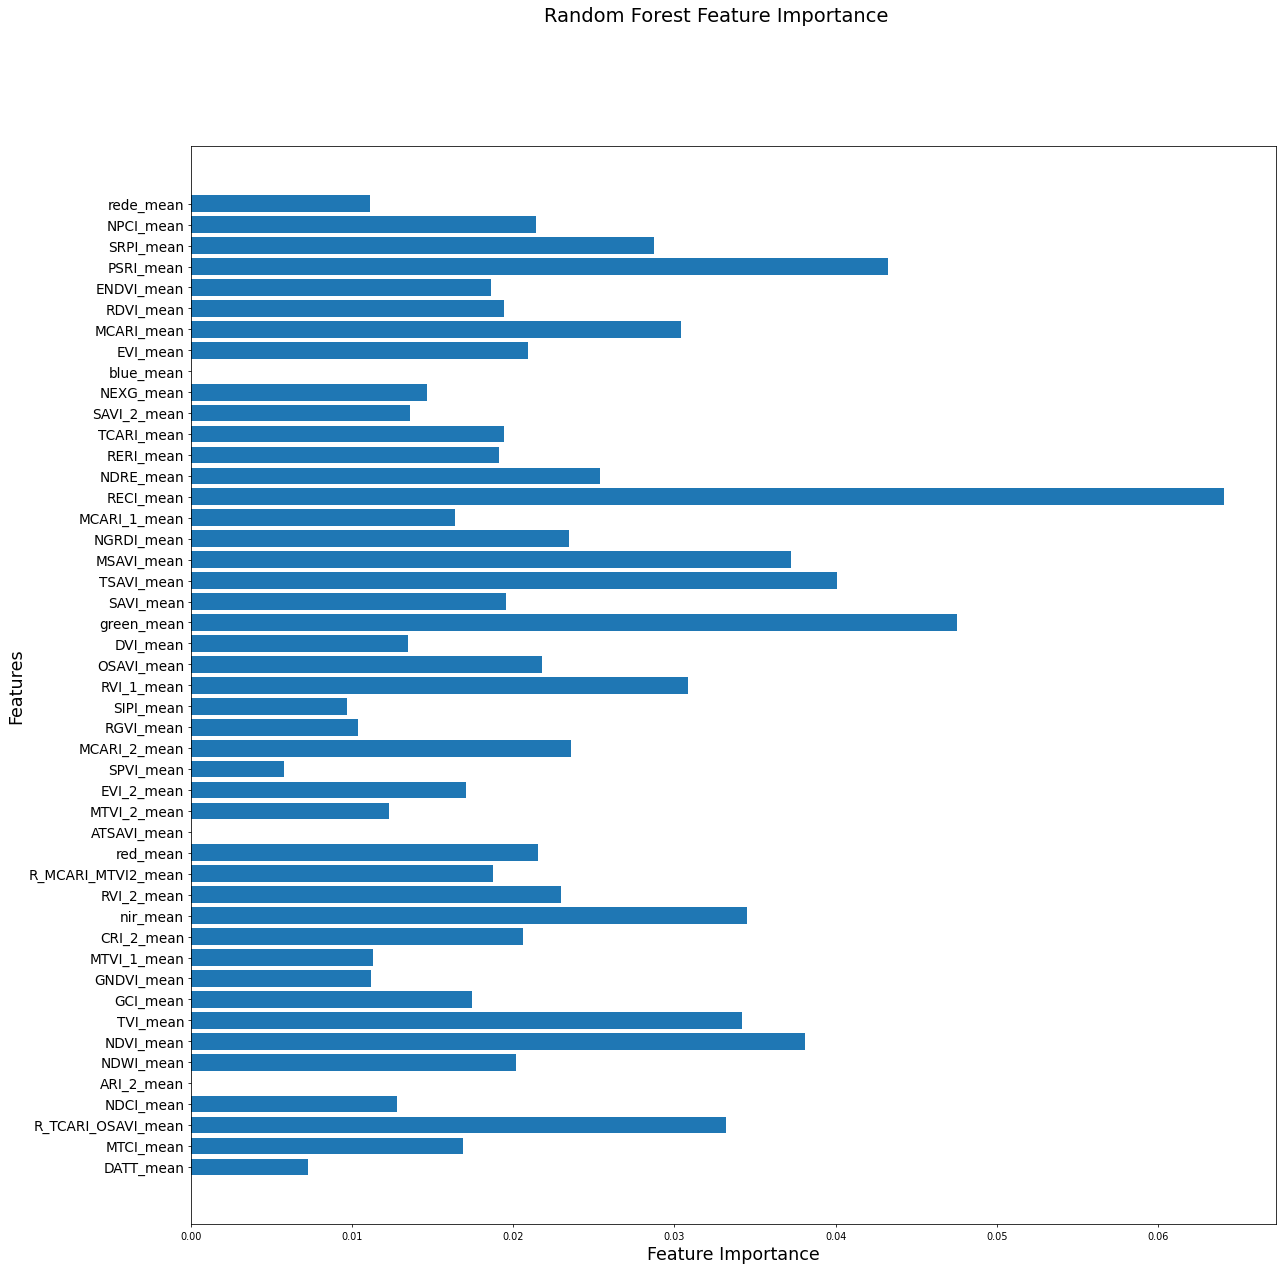

<Figure size 2000x500 with 0 Axes>

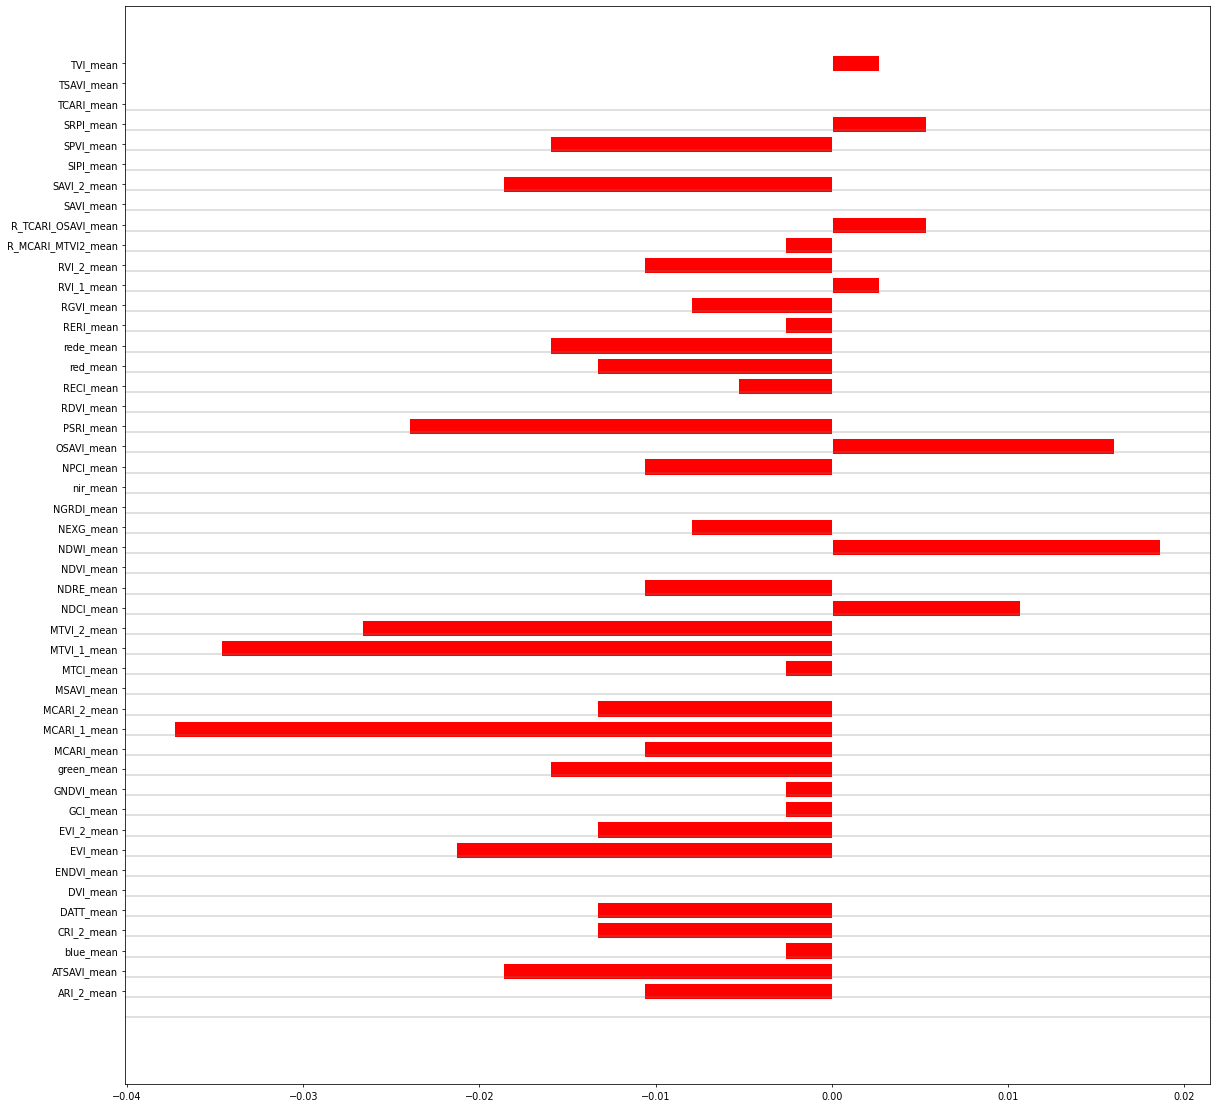

In [138]:


perm_importance_svc = permutation_importance(model, X_next_date_test, y_next_date_test, scoring='accuracy', random_state=42)
perm_importance_rfc = permutation_importance(rfc_best, X_next_date_test, y_next_date_test, scoring='accuracy', random_state=42)
perm_importance_cnn = permutation_importance(cnn_model, X_next_date_test, y_next_date_test, scoring='accuracy', random_state=42)

fig, ax = plt.subplots(1, 1, figsize=(20, 20), dpi=70)
list_feature_importance_rfc = list(rfc_best.feature_importances_)

fig.suptitle('Random Forest Feature Importance', fontsize = 20)
ax.set_ylabel('Features',  fontsize = 18)
ax.set_xlabel('Feature Importance', fontsize = 18)
plt.figure(figsize=(20, 5))

print('Columns')
X.columns = [col for col in df.columns if col != 'HEALTH_STA' and col != 'Unnamed: 0']
ax.barh(y=X.columns, width=list_feature_importance_rfc)
importance_dict = dict(zip(X.columns, list_feature_importance_rfc))
sorted_labels = sorted(importance_dict, key=lambda k: importance_dict[k])
ax.set_yticklabels(sorted_labels, fontsize=14)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(20, 20), dpi=70)
features = [col for col in df.columns if col != 'HEALTH_STA' and col != 'Unnamed: 0']

# Set the bar width
bar_height = 0.9

# Set the positions of the bars on the x-axis
r1 = np.arange(len(features))
r2 = [y + bar_height for y in r1]
r3 = [y + bar_height for y in r2]

# Add horizontal lines to group features
for i in range(1, len(features)):
    ax.axhline(i - 0.5, color='gray', linewidth=0.5)

# Create the bar chart
rects1 = ax.barh(r1, perm_importance_svc.importances_mean, color='b', edgecolor='white', tick_label=features, label='SVC')
rects2 = ax.barh(r2, perm_importance_rfc.importances_mean, color='g', edgecolor='white', tick_label=features, label='RF')
rects3 = ax.barh(r3, perm_importance_cnn.importances_mean, color='r', edgecolor='white', tick_label=features, label='CNN')

# Add x-axis labels, y-axis label, and title
#ax.set_ylabel('Features')
#ax.set_xlabel('Permutation Importances')
#fig.suptitle('Comparison of Permutation Importances for Different Models')
#print(features)
# Add x-axis tick labels
#ax.set_yticks(r1)
#ax.set_yticklabels(features, fontsize=14)
# Adjust spacing to avoid overlapping tick labels
#plt.tight_layout()

# Add a legend
#plt.legend()

# Display the plot
#plt.show()

#fig, ax = plt.subplots(1, 1, figsize=(10, 10))

#print(X.columns)

#fig.suptitle('Permutation Importance', fontsize = 20)
#plt.barh(y=X.columns, width=perm_importance_svc.importances_mean)
#importance_dict = dict(zip(X.columns, perm_importance_svc))
#print(importance_dict)
#sorted_labels = sorted(importance_dict, key=lambda k: importance_dict[k])
#print(sorted_labels)
#ax.set_yticklabels(sorted_labels, fontsize=14)
#plt.tight_layout()
#plt.show()

# Test the dataset for unhealthy
# Test using other dates as input

In [ ]:
import shap
import sklearn
import numpy 
#explainer = shap.KernelExplainer(model.predict_proba, X_train, link="logit")
#shap_values = explainer.shap_values(X_next_date_test, nsamples=100)
#print(explainer.expected_value)
#print(shap_values)

#df_shap = pd.DataFrame((zip(X.columns[np.argsort(np.abs(shap_values).mean(0))][::-1], -np.sort(-np.abs(shap_values).mean(0)))), columns=["feature", "importance"])
#explainer = shap.Explainer(xgb_clf)
#print(explainer(X_train))

#shap_values = explainer(X_train)
#shap.plots.beeswarm(explainer)

#shap.force_plot(explainer.expected_value[0], shap_values[0][0,:], X_test.iloc[0,:], matplotlib=True)



In [15]:
import shap
import time

def print_accuracy(f):
    print("Accuracy = {0}%".format(100*np.sum(f(X_next_date_test) == y_next_date_test)/len(y_next_date_test)))
    time.sleep(0.5) # to let the print get out before any progress bars


svc_linear = sklearn.svm.SVC(kernel='rbf', probability=True)
svc_linear.fit(X_train, y_train)
print_accuracy(svc_linear.predict)

# explain all the predictions in the test set
explainer = shap.KernelExplainer(svc_linear.predict_proba, X_train)
shap_values = explainer.shap_values(X_test)
shap.plots.bar(explainer(X_test), max_display=10) # default is max_display=12


Accuracy = 82.66666666666667%


Using 126 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 55/55 [03:41<00:00,  4.03s/it]


AttributeError: 'Kernel' object has no attribute 'masker'

In [11]:
from collections import Counter


print('Test', Counter(y_test))

Test Counter({0: 46, 2: 5, 1: 4})


In [10]:
force_plot = shap.force_plot(explainer.expected_value[0], shap_values[0], X_test)
from IPython.display import HTML
HTML(f"<div style='background-color:Lavender;'>{shap.getjs() + force_plot.html()}</div>")

In [21]:
!python -m pip install numpy==1.23.5

     ---------------------------------------- 0.0/14.6 MB ? eta -:--:--
     ---------------------------------------- 0.0/14.6 MB ? eta -:--:--
     ---------------------------------------- 0.1/14.6 MB 1.6 MB/s eta 0:00:09
      --------------------------------------- 0.2/14.6 MB 1.7 MB/s eta 0:00:09
      --------------------------------------- 0.3/14.6 MB 1.8 MB/s eta 0:00:09
     - -------------------------------------- 0.4/14.6 MB 1.9 MB/s eta 0:00:08
     - -------------------------------------- 0.5/14.6 MB 2.0 MB/s eta 0:00:08
     - -------------------------------------- 0.6/14.6 MB 2.1 MB/s eta 0:00:07
     -- ------------------------------------- 0.8/14.6 MB 2.2 MB/s eta 0:00:07
     -- ------------------------------------- 0.9/14.6 MB 2.3 MB/s eta 0:00:07
     -- ------------------------------------- 1.0/14.6 MB 2.2 MB/s eta 0:00:07
     -- ------------------------------------- 1.1/14.6 MB 2.2 MB/s eta 0:00:07
     --- ------------------------------------ 1.1/14.6 MB 2.1 MB/s

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\flopes1\\OneDrive - Saint Louis University\\Desktop\\Repos\\plant-disease-prediction\\myenv\\Lib\\site-packages\\~-mpy\\.libs\\libopenblas64__v0.3.21-gcc_10_3_0.dll'
Check the permissions.


[notice] A new release of pip is available: 23.0.1 -> 23.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


           0         1         2         3         4         5         6   \
166  0.322390  0.275239  0.000000  0.530258  0.379696  0.267583  0.630223   
77   0.317458  0.532856  0.741823  0.251030  0.379696  0.547023  0.506512   
130  0.805291  0.724031  0.143927  0.839646  0.379696  0.631170  0.763798   
4    0.423909  0.633488  0.115474  0.417548  0.379696  0.568262  0.912421   
120  0.483819  0.767599  0.502169  0.349690  0.379696  0.734023  0.749752   
..        ...       ...       ...       ...       ...       ...       ...   
3    0.442557  0.642603  0.288857  0.318688  0.379696  0.628102  0.894905   
179  0.617138  0.573507  0.518359  0.522595  0.379696  0.577672  0.579093   
79   0.321731  0.640990  0.686526  0.154161  0.379696  0.685227  0.686290   
33   0.346080  0.550521  0.646348  0.204074  0.379696  0.598555  0.647699   
42   0.119127  0.319508  0.912725  0.060414  0.379696  0.313351  0.366603   

           7         8         9   ...        37        38        39  \
166

ntree_limit is deprecated, use `iteration_range` or model slicing instead.


AttributeError: 'int' object has no attribute 'split'

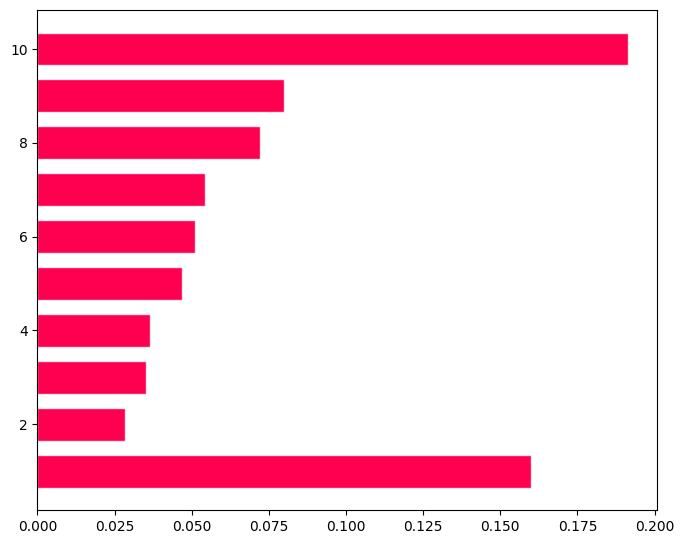

In [10]:
import xgboost
import numpy 

xgb_model = xgboost.XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)

print(X_train)
# The SHAP Values
import shap
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

shap.plots.bar(shap_values, max_display=10) # default is max_display=12


Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations


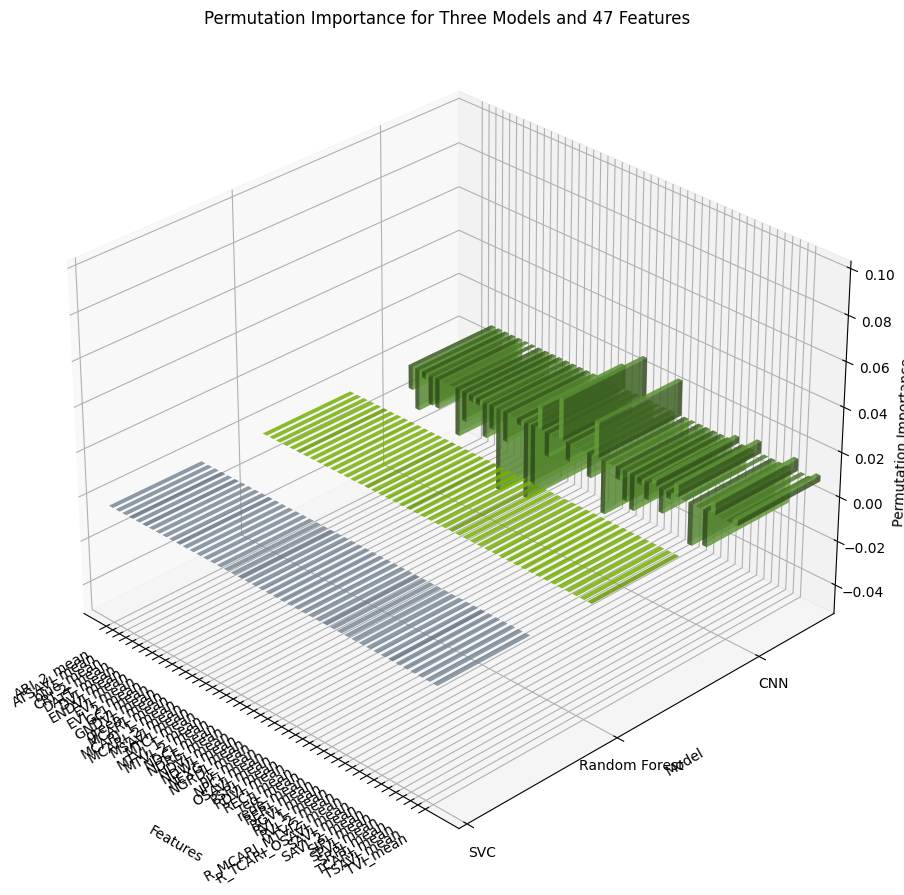

In [137]:
# Create the figure and axis
fig = plt.figure(figsize=(50, 50))
ax = fig.add_subplot(141, projection='3d')
# Define the positions for the bars
r1 = np.arange(47)
r2 = r1 + 0.25
r3 = r1 + 0.5

# Create the 3D bars for each model
ax.bar3d(r1, np.zeros_like(r1), np.zeros_like(r1), 0.6, 0.6, perm_importance_svc.importances_mean, color='#acc2d9', alpha=0.6)
ax.bar3d(r2, np.ones_like(r2), np.zeros_like(r2), 0.6, 0.6, perm_importance_rfc.importances_mean, color='#a8ff04', alpha=0.6)
ax.bar3d(r3, 2*np.ones_like(r3), np.zeros_like(r3), 0.6, 0.6, perm_importance_cnn.importances_mean, color='#70b23f', alpha=0.6)

# Set the tick labels and limits
ax.set_yticks(np.arange(3))
ax.set_xticks(np.arange(len(features)))
ax.set_xticklabels(features)
ax.tick_params(axis='both', which='major', labelsize=10)
models = ['SVC', 'Random Forest', 'CNN']
ax.set_yticklabels(models)
ax.set_ylim(0, 2.5)
ax.set_zlim(-0.050, 0.1)  # Adjust the z-axis limits as needed
plt.gcf().autofmt_xdate()
# Set labels and title
ax.set_xlabel('Features', labelpad=50)
ax.set_ylabel('Model')
ax.set_zlabel('Permutation Importance')
ax.set_title('Permutation Importance for Three Models and 47 Features')
# Adjust the view angle
ax.view_init(elev=30, azim=-45)

plt.xticks(rotation=30)
plt.tight_layout()
# Show the plot
plt.show()

In [ ]:
# Extract the dates column and remove duplicates
dates = df['date'].unique()
print(dates)
# Set the dates column as the index
df.set_index('date', inplace=True)
